# DE using RESOLVI model

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'refined-clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway_epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'plasma_leiden_n10_0.3', 'Amb_leiden_n10_0.2', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'total_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_nor

Import model

In [4]:
import scvi

# load model
model_path = '/mnt/data/project0062/proseg_data/data/comb/resolvi_model'
model = scvi.external.RESOLVI.load(
    adata=comb,
    dir_path=model_path
)

INFO     File /mnt/data/project0062/proseg_data/data/comb/resolvi_model/model.pt already downloaded                
RAPIDS SingleCell is installed and can be imported
RAPIDS SingleCell is installed and can be imported
RAPIDS SingleCell is installed and can be imported
RAPIDS SingleCell is installed and can be imported


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 0 in adata.obs['_scvi_ind_x'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
INFO: GPU available: True (cuda), used: True
2026-07-29 09:58:21 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-07-29 09:58:21 | [INFO] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-29 09:58:21 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/mnt/data/p

Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scvi/external/resolvi/_module.py:383: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  concentration=torch.tensor(
2026-07-29 09:58:29 | [INFO] Guessed max_plate_nesting = 2


Epoch 1/50:   2%|▏         | 1/50 [00:02<01:39,  2.03s/it, v_num=1]

INFO: `Trainer.fit` stopped: `max_steps=1` reached.
2026-07-29 09:58:30 | [INFO] `Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/50:   2%|▏         | 1/50 [00:02<01:40,  2.06s/it, v_num=1]


In [39]:
celltype = 'ciliated'

idx_cf = (
    (comb.obs["ann_lvl_3_refined"] == celltype)
    & (comb.obs["condition"] == "CF")
)

idx_ctrl = (
    (comb.obs["ann_lvl_3_refined"] == celltype)
    & (comb.obs["condition"] == "CTRL")
)

de_club_cf_vs_ctrl = model.differential_expression(
    comb,
    idx1=idx_cf,
    idx2=idx_ctrl,
    weights="importance",
    pseudocounts=1e-2,
    delta=0.05,
    filter_outlier_cells=True,
    mode="change",
    test_mode="three",
)


DE...: 100%|██████████| 1/1 [11:58<00:00, 718.37s/it]


In [40]:
de_club_cf_vs_ctrl.head(10)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,lfc_min,lfc_max,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05
DHCR24,0.9410,0.0590,2.769406,0.003178,0.006127,0.01,0.05,-0.911238,-0.910580,0.507535,-3.179298,4.038119,0.550257,0.576577,0.294754,0.301109,23.701776,36.647209,False
CD24,0.9270,0.0730,2.541494,0.006726,0.001816,0.01,0.05,1.692105,1.624602,1.019319,-1.256670,5.612473,0.762488,0.100312,0.370976,0.083853,35.129758,6.954959,False
CTXN1,0.9032,0.0968,2.233297,0.008123,0.003711,0.01,0.05,1.131740,1.116688,0.783883,-1.577261,5.212691,1.225476,0.319127,0.450717,0.221414,49.303725,18.593372,False
CTSD,0.9028,0.0972,2.228730,0.002538,0.005953,0.01,0.05,-1.314931,-1.297176,0.885430,-4.994725,1.829227,0.508131,0.689882,0.259212,0.349446,20.108479,49.251764,False
MUC4,0.8894,0.1106,2.084627,0.005615,0.002452,0.01,0.05,1.165085,1.199084,0.774793,-1.489354,6.619833,0.838411,0.140852,0.377543,0.115731,33.862214,9.303504,False
PHKG2,0.8810,0.1190,2.001934,0.001656,0.000364,0.01,0.05,2.581531,2.157163,1.695707,-1.088250,7.898090,0.565294,0.111920,0.299059,0.088877,26.280248,6.851175,False
TSPAN1,0.8620,0.1380,1.832002,0.012536,0.003831,0.01,0.05,1.586529,1.776458,1.039605,-1.697889,5.846177,2.026523,0.308559,0.507220,0.214484,70.844628,19.025908,False
SRI,0.8612,0.1388,1.825293,0.003172,0.006898,0.01,0.05,-1.383772,-1.427762,1.051316,-4.891873,2.851438,0.617900,0.731982,0.295901,0.343728,21.904041,45.877389,False
STMN1,0.8582,0.1418,1.800419,0.000285,0.001473,0.01,0.05,-2.285638,-2.307685,1.123047,-6.119518,1.997689,0.095470,0.208940,0.079883,0.161296,4.218992,15.551167,False
STAU1,0.8580,0.1420,1.798777,0.001678,0.000675,0.01,0.05,1.285025,1.304638,0.634065,-0.812246,5.044611,0.308989,0.053708,0.207580,0.047124,12.482605,3.058801,False


In [41]:
n_sig = de_club_cf_vs_ctrl["is_de_fdr_0.05"].sum()
print(f"{n_sig} significant genes")

0 significant genes


In [37]:
import decoupler as dc

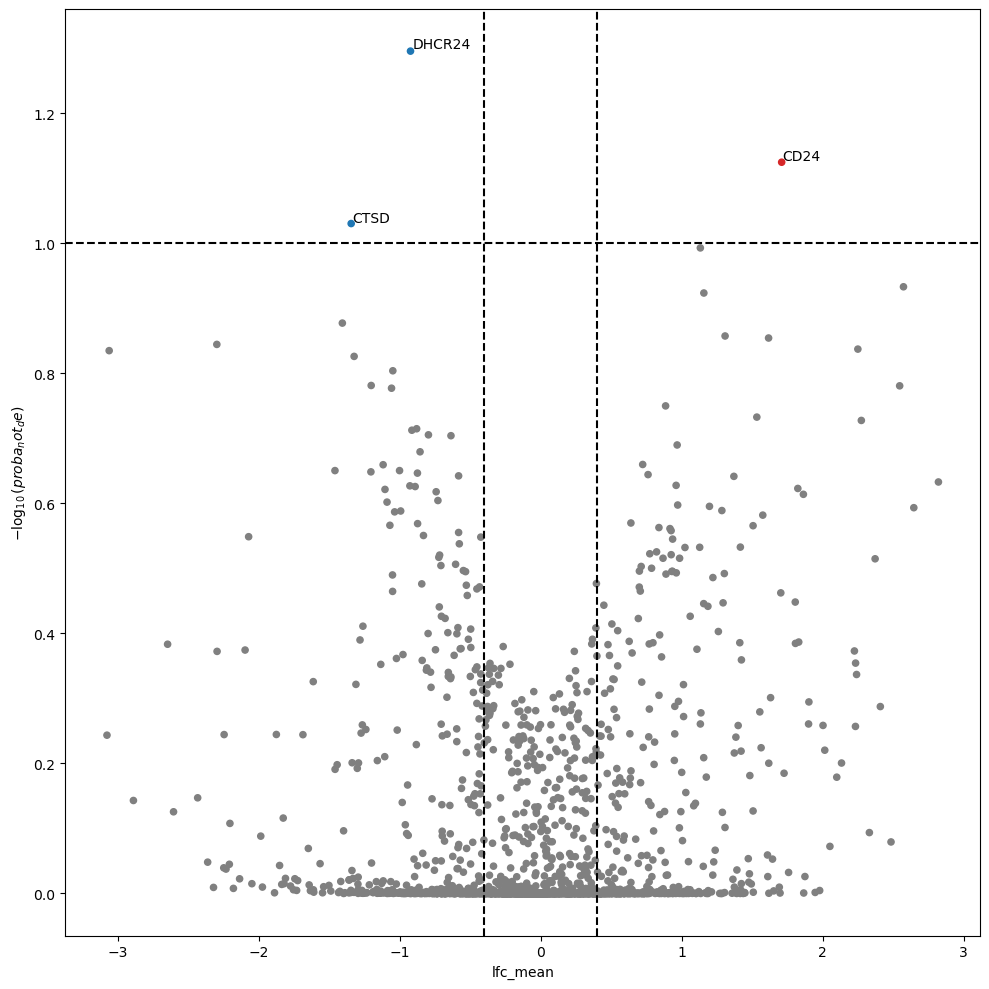

In [38]:
dc.pl.volcano(
    data=de_club_cf_vs_ctrl,
    x="lfc_mean",
    y="proba_not_de",
    thr_stat=0.4,
    thr_sign=0.1,
    top=30,
    figsize=(10, 10),
)